# NFL Data Project

## Data Imports

In [14]:
import re
import os
import pandas as pd
import numpy as np
import math
import glob
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from mpl_toolkits.mplot3d import Axes3D

import warnings
warnings.filterwarnings("ignore")

In [15]:
nfl = pd.read_csv('nfl_team_stats_2002-2023.csv')
nfl

,season,week,date,away,home,score_away,score_home,first_downs_away,first_downs_home,third_down_comp_away,...,redzone_comp_home,redzone_att_home,fumbles_away,fumbles_home,interceptions_away,interceptions_home,def_st_td_away,def_st_td_home,possession_away,possession_home
0,2002,1,2002-09-05,49ers,Giants,16,13,13,21,4,...,0,6,0,0,1,3,0,0,27:32,32:28
1,2002,1,2002-09-08,Jets,Bills,37,31,18,26,2,...,0,8,1,1,0,2,2,0,21:06,39:08
2,2002,1,2002-09-08,Vikings,Bears,23,27,19,20,5,...,0,6,1,1,2,1,0,0,31:31,28:29
3,2002,1,2002-09-08,Chargers,Bengals,34,6,27,13,6,...,0,5,0,0,0,1,0,0,37:48,22:12
4,2002,1,2002-09-08,Chiefs,Browns,40,39,24,24,5,...,0,10,0,1,1,0,0,0,30:16,29:44
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5924,2023,Division,2024-01-21,Buccaneers,Lions,23,31,23,26,4,...,3,4,0,0,2,0,0,0,28:00,32:00
5925,2023,Division,2024-01-21,Chiefs,Bills,27,24,21,27,1,...,3,4,1,0,0,0,0,0,22:57,37:03
5926,2023,Conference,2024-01-28,Chiefs,Ravens,17,10,22,16,8,...,0,1,0,2,0,1,0,0,37:30,22:30
5927,2023,Conference,2024-01-28,Lions,49ers,31,34,28,23,6,...,4,5,1,0,0,1,0,0,27:48,32:12


## Data Preprocessing

### Understanding the Data

In [16]:
nfl.dtypes

season                    int64
week                     object
date                     object
away                     object
home                     object
score_away                int64
score_home                int64
first_downs_away          int64
first_downs_home          int64
third_down_comp_away      int64
third_down_att_away       int64
third_down_comp_home      int64
third_down_att_home       int64
fourth_down_comp_away     int64
fourth_down_att_away      int64
fourth_down_comp_home     int64
fourth_down_att_home      int64
plays_away                int64
plays_home                int64
drives_away               int64
drives_home               int64
yards_away                int64
yards_home                int64
pass_comp_away            int64
pass_att_away             int64
pass_yards_away           int64
pass_comp_home            int64
pass_att_home             int64
pass_yards_home           int64
sacks_num_away            int64
sacks_yards_away          int64
sacks_nu

In [17]:
nfl.describe()

,season,score_away,score_home,first_downs_away,first_downs_home,third_down_comp_away,third_down_att_away,third_down_comp_home,third_down_att_home,fourth_down_comp_away,...,redzone_comp_away,redzone_att_away,redzone_comp_home,redzone_att_home,fumbles_away,fumbles_home,interceptions_away,interceptions_home,def_st_td_away,def_st_td_home
count,5929.000000,5929.000000,5929.000000,5929.000000,5929.000000,5929.000000,5929.000000,5929.000000,5929.000000,5929.00000,...,5929.000000,5929.000000,5929.000000,5929.000000,5929.000000,5929.000000,5929.000000,5929.000000,5929.000000,5929.000000
mean,2012.587452,21.100523,23.401585,19.016360,19.969135,5.068308,13.264294,5.232248,13.142182,0.53972,...,1.273908,3.230899,1.432619,3.474616,0.628942,0.626413,0.942149,0.883623,0.311182,0.324169
std,6.380254,10.048298,10.275054,5.070046,4.963860,2.259159,2.524804,2.238903,2.570961,0.77895,...,1.238522,1.940881,1.339812,1.933285,0.805019,0.791689,1.011169,0.992524,0.758984,0.780038
min,2002.000000,0.000000,0.000000,3.000000,3.000000,0.000000,5.000000,0.000000,5.000000,0.00000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2007.000000,14.000000,17.000000,15.000000,17.000000,3.000000,12.000000,4.000000,11.000000,0.00000,...,0.000000,2.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,2013.000000,20.000000,23.000000,19.000000,20.000000,5.000000,13.000000,5.000000,13.000000,0.00000,...,1.000000,3.000000,1.000000,3.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000
75%,2018.000000,28.000000,30.000000,22.000000,23.000000,7.000000,15.000000,7.000000,15.000000,1.00000,...,2.000000,4.000000,2.000000,5.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000
max,2023.000000,59.000000,70.000000,37.000000,40.000000,15.000000,24.000000,15.000000,24.000000,6.00000,...,6.000000,15.000000,7.000000,14.000000,5.000000,4.000000,6.000000,6.000000,6.000000,6.000000


In [18]:
# Group by 'season' and count rows
season_counts = nfl.groupby('season').size()

print(season_counts)

season
2002    267
2003    267
2004    267
2005    267
2006    267
2007    267
2008    267
2009    267
2010    267
2011    267
2012    267
2013    267
2014    267
2015    267
2016    267
2017    267
2018    267
2019    267
2020    269
2021    285
2022    284
2023    285
dtype: int64


In 2020, the NFL added an extra playoff spot in each conference, leading to 2 more playoffs games.

In 2021, the NFL added an additional regualr season game, leading to 16 more regular season games.

In 2022, there was an on-field incident causing a cancellation of the match, leading to 1 less regualr season game.

In [19]:
nfl['week'].value_counts()

week
16            352
15            352
1             351
2             351
17            351
14            346
12            345
13            344
3             342
11            327
4             323
5             314
10            311
6             310
8             307
7             306
9             299
Wildcard       96
Division       88
18             48
Conference     44
Superbowl      22
Name: count, dtype: int64

Bye weeks affect the distribution of games by week.

In [20]:
nRow, nCol = nfl.shape
print(f'There are {nRow} rows and {nCol} columns.')

print("\nList of columns:\n")
print(nfl.columns.tolist())

There are 5929 rows and 53 columns.

List of columns:

['season', 'week', 'date', 'away', 'home', 'score_away', 'score_home', 'first_downs_away', 'first_downs_home', 'third_down_comp_away', 'third_down_att_away', 'third_down_comp_home', 'third_down_att_home', 'fourth_down_comp_away', 'fourth_down_att_away', 'fourth_down_comp_home', 'fourth_down_att_home', 'plays_away', 'plays_home', 'drives_away', 'drives_home', 'yards_away', 'yards_home', 'pass_comp_away', 'pass_att_away', 'pass_yards_away', 'pass_comp_home', 'pass_att_home', 'pass_yards_home', 'sacks_num_away', 'sacks_yards_away', 'sacks_num_home', 'sacks_yards_home', 'rush_att_away', 'rush_yards_away', 'rush_att_home', 'rush_yards_home', 'pen_num_away', 'pen_yards_away', 'pen_num_home', 'pen_yards_home', 'redzone_comp_away', 'redzone_att_away', 'redzone_comp_home', 'redzone_att_home', 'fumbles_away', 'fumbles_home', 'interceptions_away', 'interceptions_home', 'def_st_td_away', 'def_st_td_home', 'possession_away', 'possession_home']


In [21]:
# Display the number of null values by column
columns_with_nulls = nfl.columns[nfl.isnull().any()]
null_values_by_column = nfl[columns_with_nulls].isnull().sum()
print(null_values_by_column)

Series([], dtype: float64)


There are no null values in the data to address.

In [22]:
# end of the dataset
nfl.iloc[5500:, ]

,season,week,date,away,home,score_away,score_home,first_downs_away,first_downs_home,third_down_comp_away,...,redzone_comp_home,redzone_att_home,fumbles_away,fumbles_home,interceptions_away,interceptions_home,def_st_td_away,def_st_td_home,possession_away,possession_home
5500,2022,10,2022-11-13,Broncos,Titans,10,17,18,14,4,...,1,2,0,1,1,0,0,0,33:57,26:03
5501,2022,10,2022-11-13,Jaguars,Chiefs,17,27,17,26,4,...,4,5,0,2,0,1,0,0,31:39,28:21
5502,2022,10,2022-11-13,Browns,Dolphins,17,39,20,29,5,...,3,5,1,0,0,0,0,0,26:46,33:14
5503,2022,10,2022-11-13,Texans,Giants,16,24,22,19,3,...,2,2,1,0,1,0,0,0,26:40,33:20
5504,2022,10,2022-11-13,Saints,Steelers,10,20,10,28,3,...,2,5,0,0,2,0,0,0,21:04,38:56
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5924,2023,Division,2024-01-21,Buccaneers,Lions,23,31,23,26,4,...,3,4,0,0,2,0,0,0,28:00,32:00
5925,2023,Division,2024-01-21,Chiefs,Bills,27,24,21,27,1,...,3,4,1,0,0,0,0,0,22:57,37:03
5926,2023,Conference,2024-01-28,Chiefs,Ravens,17,10,22,16,8,...,0,1,0,2,0,1,0,0,37:30,22:30
5927,2023,Conference,2024-01-28,Lions,49ers,31,34,28,23,6,...,4,5,1,0,0,1,0,0,27:48,32:12


### Data Wrangling

In [28]:
# Create 'home_win' column
nfl['home_win'] = 'No'
nfl.loc[nfl['score_home'] > nfl['score_away'], 'home_win'] = 'Yes'
nfl.loc[nfl['score_home'] == nfl['score_away'], 'home_win'] = 'Tied'

# Create 'away_win' column
nfl['away_win'] = 'No'
nfl.loc[nfl['score_home'] < nfl['score_away'], 'away_win'] = 'Yes'
nfl.loc[nfl['score_home'] == nfl['score_away'], 'away_win'] = 'Tied'

# Create 'winner' column
nfl['winner'] = nfl['home'].where(nfl['home_win'] == 'Yes', nfl['away'])
nfl.loc[nfl['home_win'] == 'Tied', 'winner'] = 'Tie'

# Create 'winning_team' column
nfl['winning_team'] = nfl.apply(lambda row: 'home' if row['home_win'] == 'Yes' else ('away' if row['home_win'] == 'No' else 'tie'), axis=1)

In [24]:
# Third down conversion rates
nfl['third_down_rate_home'] = nfl['third_down_comp_home']/nfl['third_down_att_home']
nfl['third_down_rate_away'] = nfl['third_down_comp_away']/nfl['third_down_att_away']

# Fourth down conversion rates
nfl['fourth_down_rate_home'] = nfl['fourth_down_comp_home'] / nfl['fourth_down_att_home']
nfl['fourth_down_rate_away'] = nfl['fourth_down_comp_away'] / nfl['fourth_down_att_away']

In [29]:
nfl.head()

,season,week,date,away,home,score_away,score_home,first_downs_away,first_downs_home,third_down_comp_away,...,possession_away,possession_home,home_win,away_win,winner,third_down_rate_home,third_down_rate_away,fourth_down_rate_home,fourth_down_rate_away,winning_team
0,2002,1,2002-09-05,49ers,Giants,16,13,13,21,4,...,27:32,32:28,No,Yes,49ers,0.562500,0.333333,0.0,NaN,away
1,2002,1,2002-09-08,Jets,Bills,37,31,18,26,2,...,21:06,39:08,No,Yes,Jets,0.411765,0.250000,1.0,NaN,away
2,2002,1,2002-09-08,Vikings,Bears,23,27,19,20,5,...,31:31,28:29,Yes,No,Bears,0.538462,0.384615,NaN,NaN,home
3,2002,1,2002-09-08,Chargers,Bengals,34,6,27,13,6,...,37:48,22:12,No,Yes,Chargers,0.363636,0.600000,NaN,NaN,away
4,2002,1,2002-09-08,Chiefs,Browns,40,39,24,24,5,...,30:16,29:44,No,Yes,Chiefs,0.363636,0.454545,NaN,NaN,away


### Exploratory Data Analysis

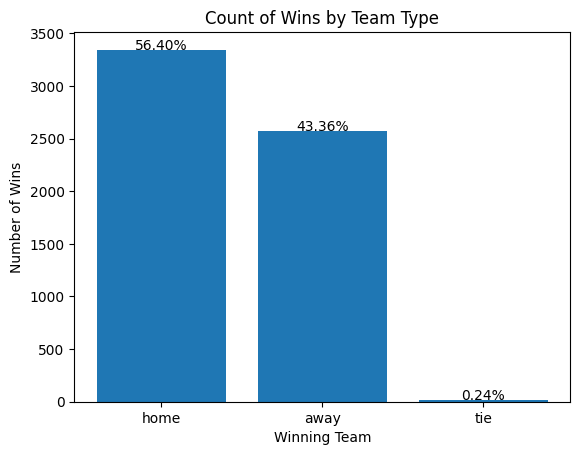

In [32]:
# Count occurrences of each value in the 'winning_team' column
winning_team_counts = nfl['winning_team'].value_counts()

# Calculate percentages
total_games = winning_team_counts.sum()
percentages = (winning_team_counts / total_games) * 100

# Plot the bar plot
plt.bar(winning_team_counts.index, winning_team_counts.values)

# Add labels and title
plt.xlabel('Winning Team')
plt.ylabel('Number of Wins')
plt.title('Count of Wins by Team Type')

# Annotate bars with percentages
for i, percentage in enumerate(percentages):
    plt.text(i, winning_team_counts[i] + 0.5, f'{percentage:.2f}%', ha='center')

# Show the plot
plt.show()


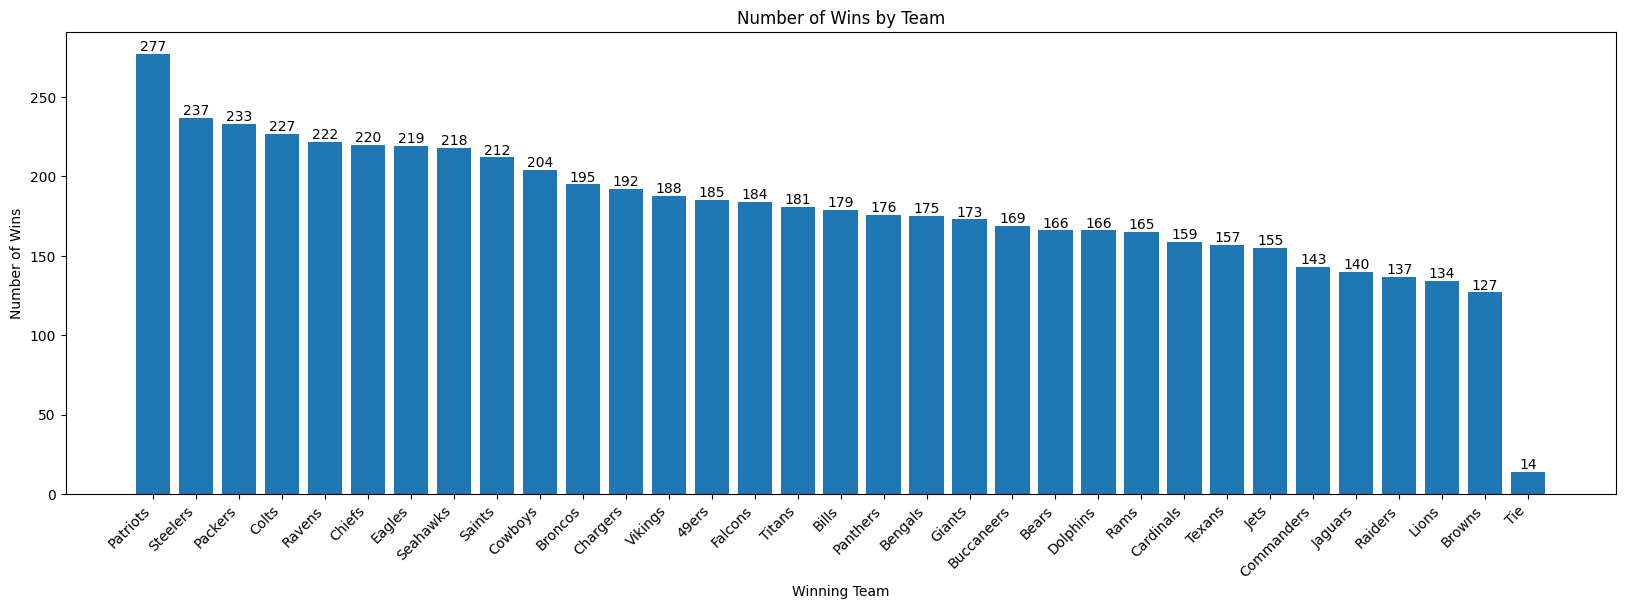

In [38]:
# Set the figure size
plt.figure(figsize=(20, 6))

# Count occurrences of each value in the 'winner' column
winner_counts = nfl['winner'].value_counts()

# Plot the bar plot
bars = plt.bar(winner_counts.index, winner_counts.values)

# Add labels for each bar
for bar in bars:
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), str(int(bar.get_height())), 
             ha='center', va='bottom')

# Add labels and title
plt.xlabel('Winning Team')
plt.ylabel('Number of Wins')
plt.title('Number of Wins by Team')

# Rotate team names diagonally
plt.xticks(rotation=45, ha='right')

# Show the plot
plt.show()

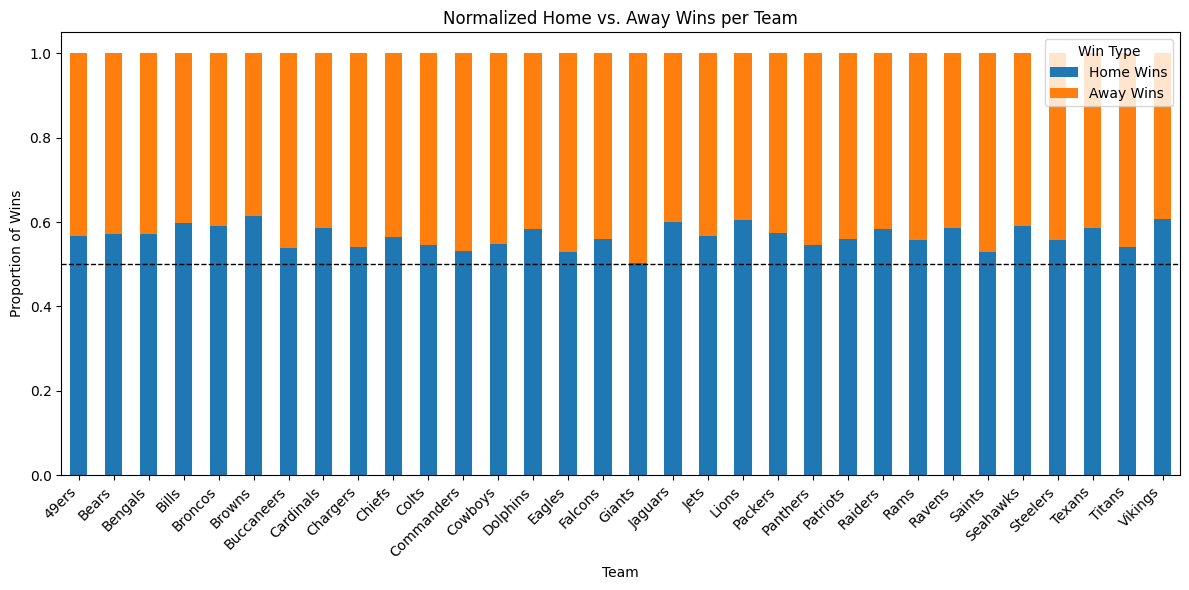

In [42]:
# Calculate total home and away wins
home_wins = nfl[nfl['home_win'] == 'Yes']['winner'].value_counts()
away_wins = nfl[nfl['home_win'] == 'No']['winner'].value_counts()

# Combine into a DataFrame
wins_df = pd.DataFrame({'Home Wins': home_wins, 'Away Wins': away_wins}).fillna(0)

# Normalize the data
wins_df_normalized = wins_df.div(wins_df.sum(axis=1), axis=0)

# Plot the normalized bar chart
ax = wins_df_normalized.plot(kind='bar', stacked=True, figsize=(12, 6))

# Add labels and title
plt.xlabel('Team')
plt.ylabel('Proportion of Wins')
plt.title('Normalized Home vs. Away Wins per Team')

ax.axhline(y=0.5, color='black', linestyle='--', linewidth=1)

# Show the plot
plt.legend(title='Win Type')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

The next 3 visualizations are iterations of https://www.kaggle.com/code/kerneler/starter-nfl-team-stats-2002-2019-27043d62-f 

In [9]:
# Distribution graphs (histogram/bar graph) of column data
def plotPerColumnDistribution(df, nGraphShown, nGraphPerRow):
    nunique = df.nunique()
    df = df[[col for col in df if nunique[col] > 1 and nunique[col] < 50]] # For displaying purposes, pick columns that have between 1 and 50 unique values
    nRow, nCol = df.shape
    columnNames = list(df)
    nGraphRow = math.ceil((nCol + nGraphPerRow - 1) / nGraphPerRow)
    plt.figure(num = None, figsize = (6 * nGraphPerRow, 8 * nGraphRow), dpi = 80, facecolor = 'w', edgecolor = 'k')
    for i in range(min(nCol, nGraphShown)):
        plt.subplot(nGraphRow, nGraphPerRow, i + 1)
        columnDf = df.iloc[:, i]
        if (not np.issubdtype(type(columnDf.iloc[0]), np.number)):
            valueCounts = columnDf.value_counts()
            valueCounts.plot.bar()
        else:
            columnDf.hist()
        plt.ylabel('counts')
        plt.xticks(rotation = 90)
        plt.title(f'{columnNames[i]} (column {i})')
    plt.tight_layout(pad = 1.0, w_pad = 1.0, h_pad = 1.0)
    plt.show()

In [10]:
# Correlation matrix
def plotCorrelationMatrix(df, graphWidth):
    filename = "cool"
    df = df[[col for col in df if df[col].nunique() > 1]] # keep columns where there are more than 1 unique values
    if df.shape[1] < 2:
        print(f'No correlation plots shown: The number of non-NaN or constant columns ({df.shape[1]}) is less than 2')
        return
    corr = df.corr()
    plt.figure(num=None, figsize=(graphWidth, graphWidth), dpi=80, facecolor='w', edgecolor='k')
    corrMat = plt.matshow(corr, fignum = 1)
    plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
    plt.yticks(range(len(corr.columns)), corr.columns)
    plt.gca().xaxis.tick_bottom()
    plt.colorbar(corrMat)
    plt.title(f'Correlation Matrix for {filename}', fontsize=15)
    plt.show()

In [11]:
def plotCorrelationMatrix(df, graphWidth, plot_title):
    numeric_df = df.select_dtypes(include=['number'])  # Select only numeric columns
    if numeric_df.shape[1] < 2:
        print(f'No correlation plots shown: The number of numeric columns ({numeric_df.shape[1]}) is less than 2')
        return
    corr = numeric_df.corr()
    plt.figure(num=None, figsize=(graphWidth, graphWidth), dpi=80, facecolor='w', edgecolor='k')
    corrMat = plt.matshow(corr, fignum=1)
    plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
    plt.yticks(range(len(corr.columns)), corr.columns)
    plt.gca().xaxis.tick_bottom()
    plt.colorbar(corrMat)
    plt.title(f'Correlation Matrix for {plot_title}', fontsize=15)
    plt.show()

In [12]:
# Scatter and density plots
def plotScatterMatrix(df, plotSize, textSize):
    df = df.select_dtypes(include =[np.number]) # keep only numerical columns
    # Remove rows and columns that would lead to df being singular
    df = df[[col for col in df if df[col].nunique() > 1]] # keep columns where there are more than 1 unique values
    columnNames = list(df)
    if len(columnNames) > 10: # reduce the number of columns for matrix inversion of kernel density plots
        columnNames = columnNames[:10]
    df = df[columnNames]
    ax = pd.plotting.scatter_matrix(df, alpha=0.75, figsize=[plotSize, plotSize], diagonal='kde')
    corrs = df.corr().values
    for i, j in zip(*plt.np.triu_indices_from(ax, k = 1)):
        ax[i, j].annotate('Corr. = %.3f' % corrs[i, j], (0.65, 0.2), xycoords='axes fraction', ha='center', va='center', size=textSize)
    plt.suptitle('Scatter and Density Plot')
    plt.show()

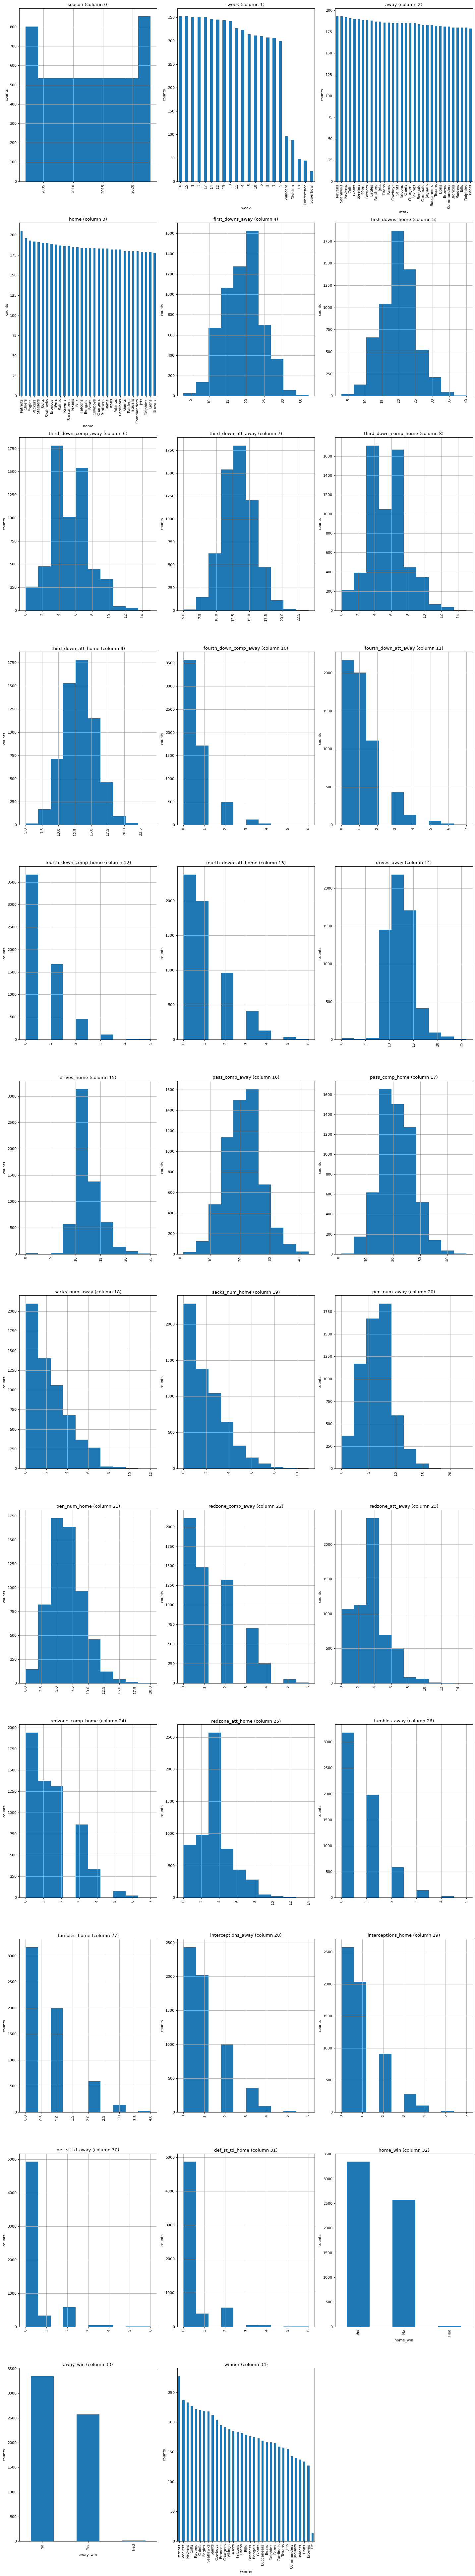

In [13]:
plotPerColumnDistribution(nfl, 35, 3)

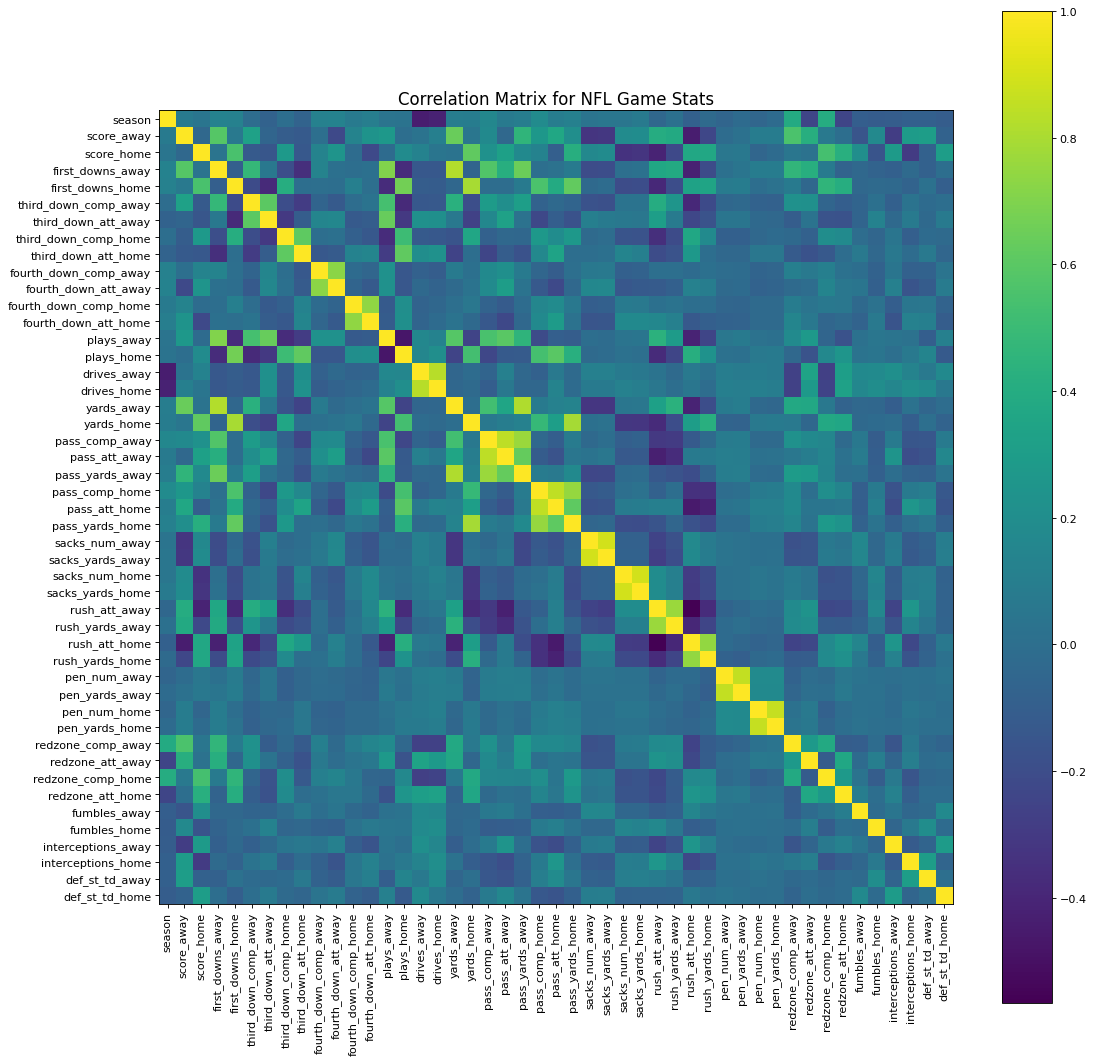

In [14]:
plotCorrelationMatrix(nfl, 16, "NFL Game Stats")

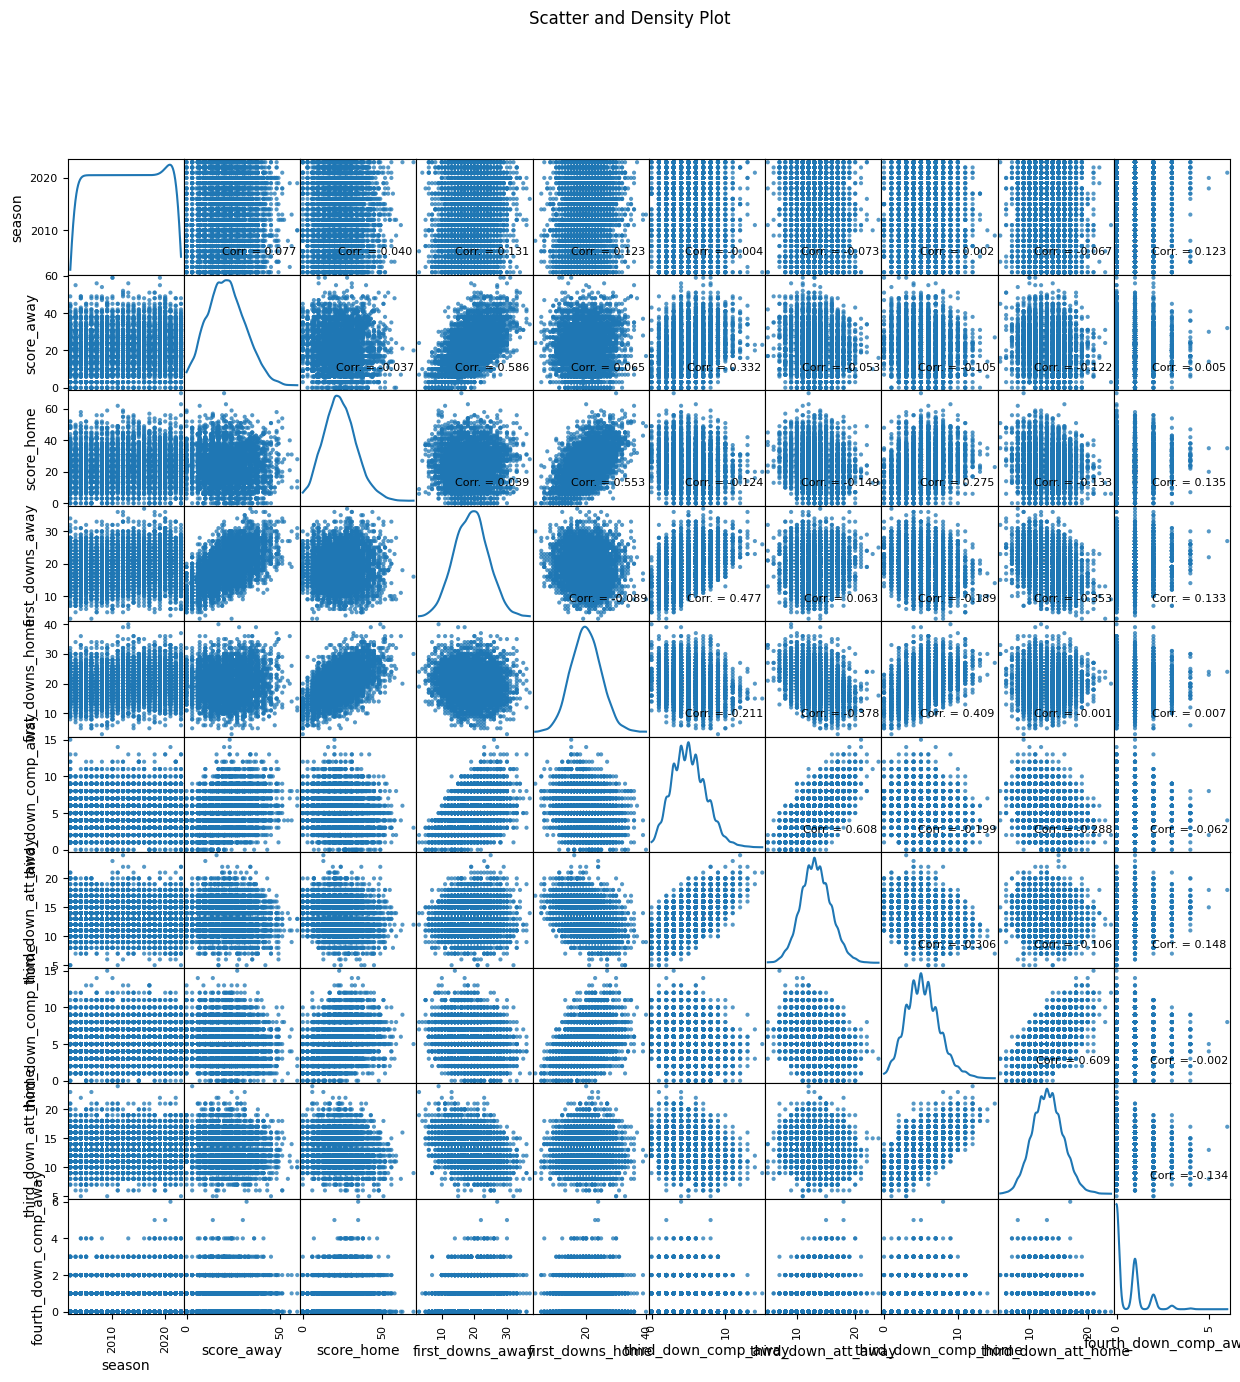

In [15]:
plotScatterMatrix(nfl, 15, 8)

A look into the connections between yards and scoring:

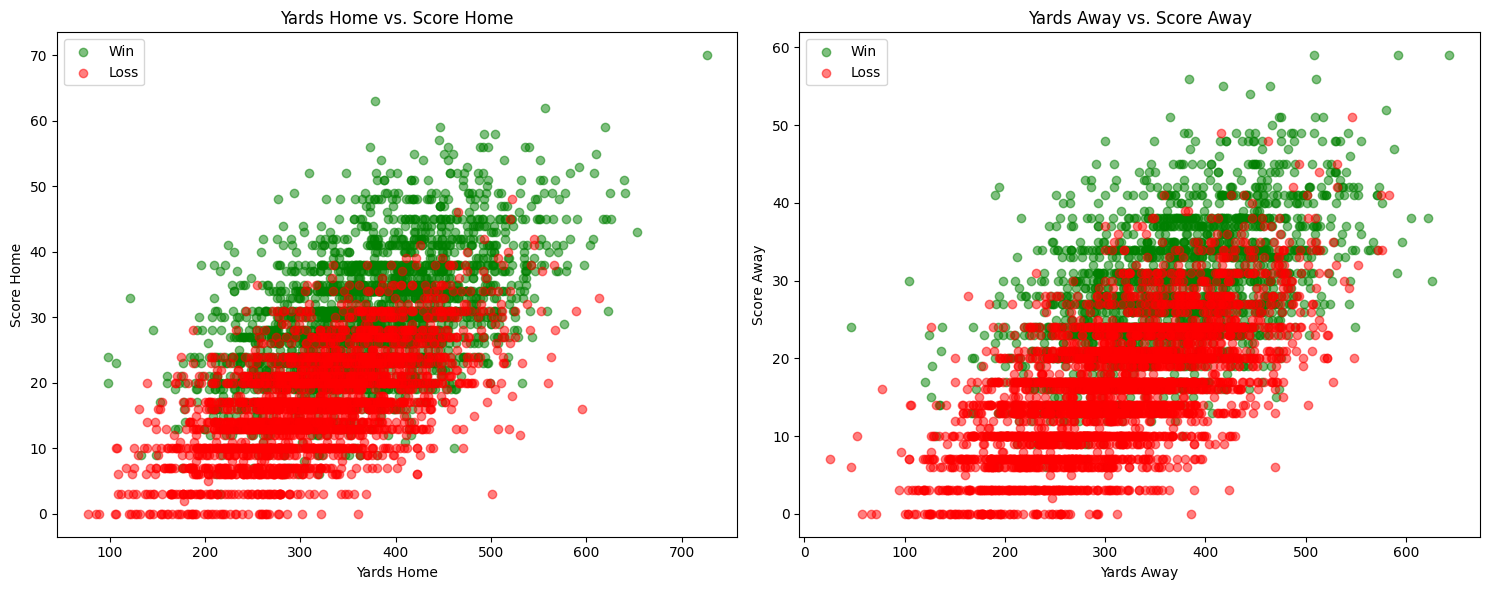

In [48]:
# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Scatter plot for yards_home vs. score_home
for outcome, color in [('Yes', 'green'), ('No', 'red')]:
    axes[0].scatter(nfl[nfl['home_win'] == outcome]['yards_home'], 
                    nfl[nfl['home_win'] == outcome]['score_home'], 
                    color=color, alpha=0.5, label= 'Win' if outcome == 'Yes' else 'Loss')

axes[0].set_xlabel('Yards Home')
axes[0].set_ylabel('Score Home')
axes[0].set_title('Yards Home vs. Score Home')
axes[0].legend()

# Scatter plot for yards_away vs. score_away
for outcome, color in [('Yes', 'green'), ('No', 'red')]:
    axes[1].scatter(nfl[nfl['away_win'] == outcome]['yards_away'], 
                    nfl[nfl['away_win'] == outcome]['score_away'], 
                    color=color, alpha=0.5, label= 'Win' if outcome == 'Yes' else 'Loss')

axes[1].set_xlabel('Yards Away')
axes[1].set_ylabel('Score Away')
axes[1].set_title('Yards Away vs. Score Away')
axes[1].legend()

# Show the plot
plt.tight_layout()
plt.show()


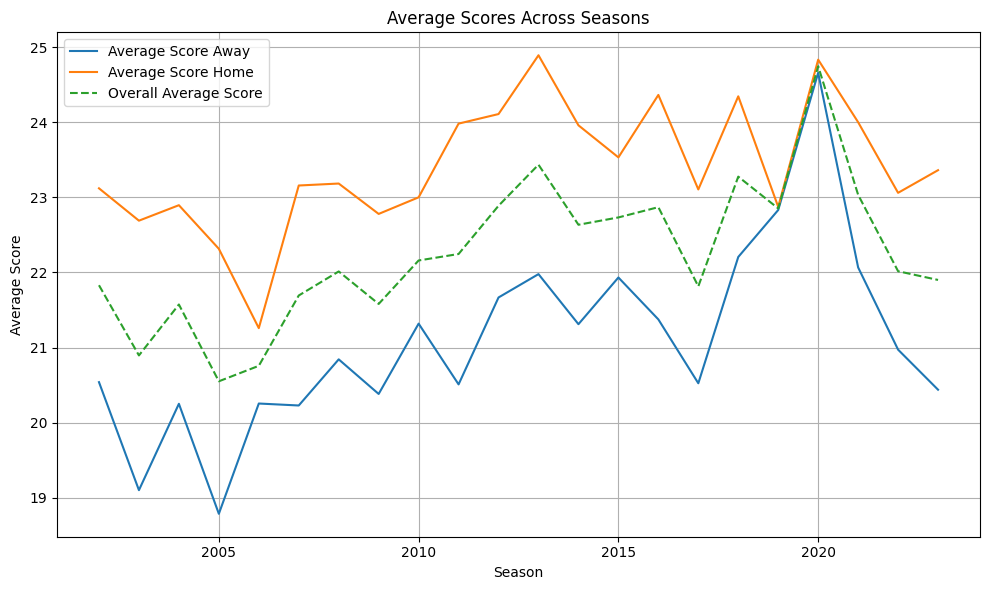

In [50]:
# Calculate average score_away and score_home for each season
avg_score_away = nfl.groupby('season')['score_away'].mean()
avg_score_home = nfl.groupby('season')['score_home'].mean()

# Calculate overall average of score_away and score_home
avg_score_total = (avg_score_away + avg_score_home) / 2

# Plot the lines
plt.figure(figsize=(10, 6))
plt.plot(avg_score_away.index, avg_score_away, label='Average Score Away')
plt.plot(avg_score_home.index, avg_score_home, label='Average Score Home')
plt.plot(avg_score_total.index, avg_score_total, label='Overall Average Score', linestyle='--')

# Add labels and title
plt.xlabel('Season')
plt.ylabel('Average Score')
plt.title('Average Scores Across Seasons')
plt.legend()

# Show the plot
plt.grid(True)
plt.tight_layout()
plt.show()

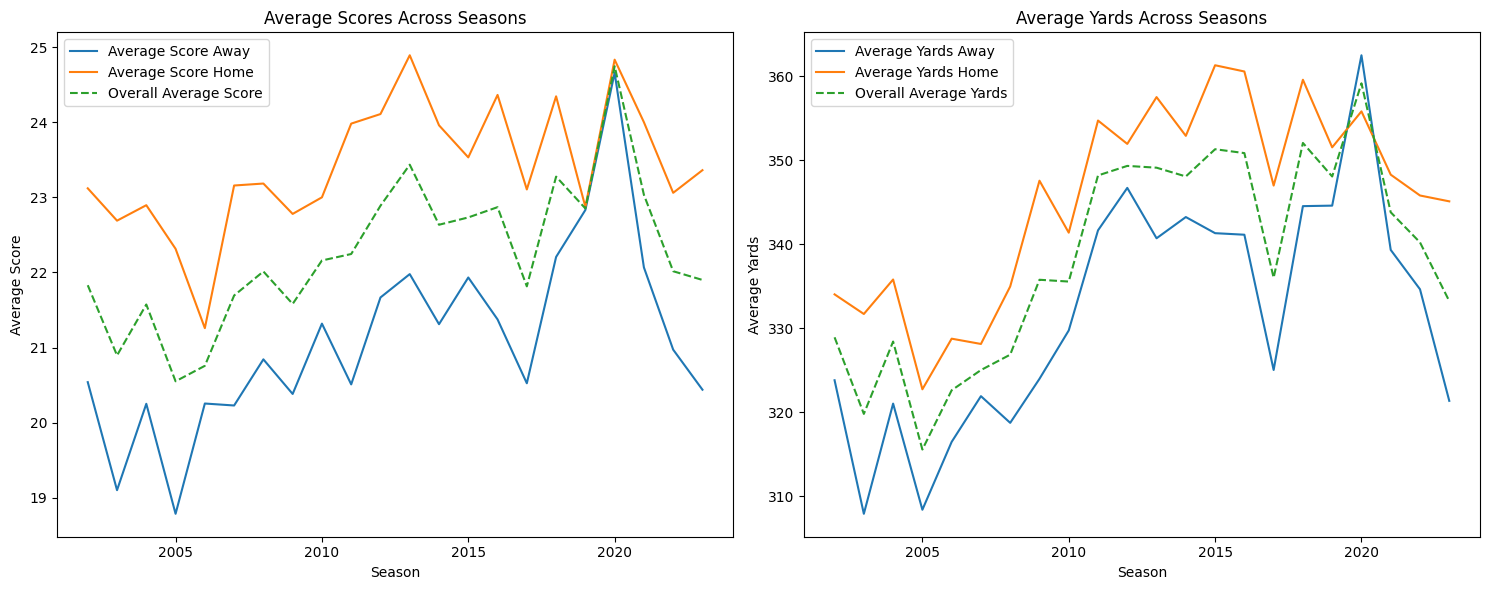

In [52]:
# Calculate average score_away, score_home, and average total score for each season
avg_score_away = nfl.groupby('season')['score_away'].mean()
avg_score_home = nfl.groupby('season')['score_home'].mean()
avg_score_total = (avg_score_away + avg_score_home) / 2

# Calculate average yards_away, yards_home, and average total yards for each season
avg_yards_away = nfl.groupby('season')['yards_away'].mean()
avg_yards_home = nfl.groupby('season')['yards_home'].mean()
avg_yards_total = (avg_yards_away + avg_yards_home) / 2

# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Plot for scores
axes[0].plot(avg_score_away.index, avg_score_away, label='Average Score Away')
axes[0].plot(avg_score_home.index, avg_score_home, label='Average Score Home')
axes[0].plot(avg_score_total.index, avg_score_total, label='Overall Average Score', linestyle='--')
axes[0].set_xlabel('Season')
axes[0].set_ylabel('Average Score')
axes[0].set_title('Average Scores Across Seasons')
axes[0].legend()

# Plot for yards
axes[1].plot(avg_yards_away.index, avg_yards_away, label='Average Yards Away')
axes[1].plot(avg_yards_home.index, avg_yards_home, label='Average Yards Home')
axes[1].plot(avg_yards_total.index, avg_yards_total, label='Overall Average Yards', linestyle='--')
axes[1].set_xlabel('Season')
axes[1].set_ylabel('Average Yards')
axes[1].set_title('Average Yards Across Seasons')
axes[1].legend()

# Show the plot
plt.tight_layout()
plt.show()

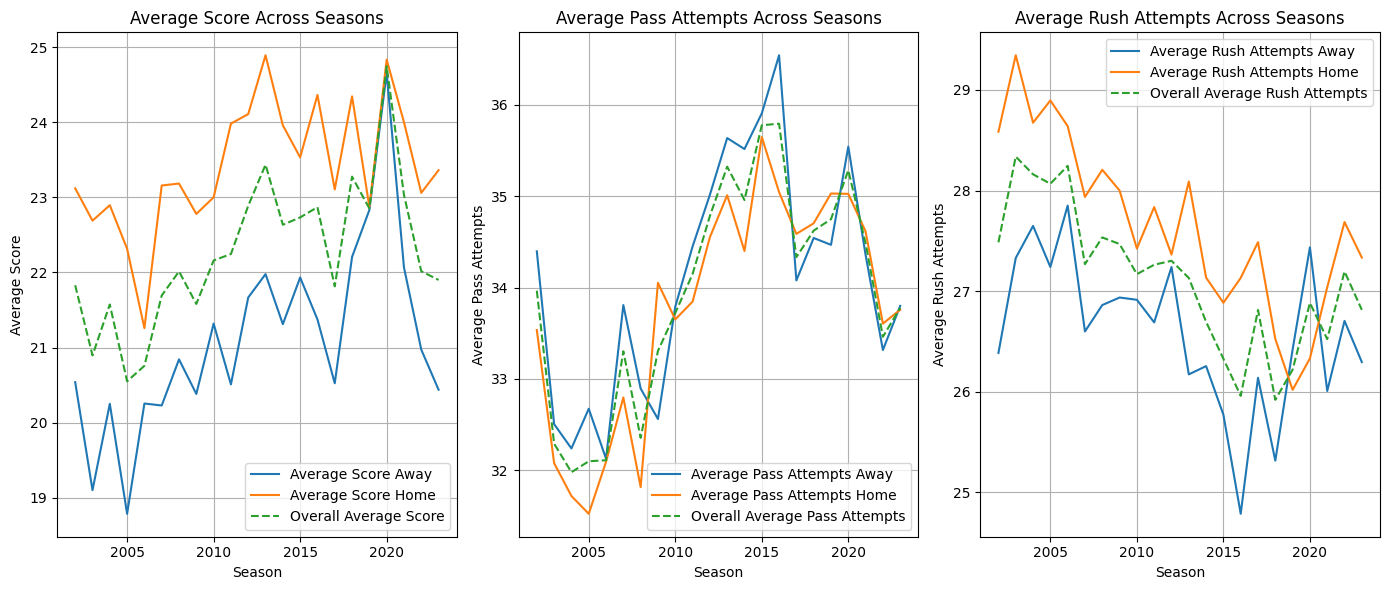

In [55]:
# Create subplots for scores and pass attempts
fig, axes = plt.subplots(1, 3, figsize=(14, 6))

# Calculate average scores for each season
avg_score_away = nfl.groupby('season')['score_away'].mean()
avg_score_home = nfl.groupby('season')['score_home'].mean()
avg_score_total = (avg_score_away + avg_score_home) / 2

# Plot for scores
axes[0].plot(avg_score_away.index, avg_score_away, label='Average Score Away')
axes[0].plot(avg_score_home.index, avg_score_home, label='Average Score Home')
axes[0].plot(avg_score_total.index, avg_score_total, label='Overall Average Score', linestyle='--')
axes[0].set_xlabel('Season')
axes[0].set_ylabel('Average Score')
axes[0].set_title('Average Score Across Seasons')
axes[0].legend()
axes[0].grid(True)

# Calculate average pass attempts for each season
avg_pass_att_away = nfl.groupby('season')['pass_att_away'].mean()
avg_pass_att_home = nfl.groupby('season')['pass_att_home'].mean()
avg_pass_att_total = (avg_pass_att_away + avg_pass_att_home) / 2

# Plot for pass attempts
axes[1].plot(avg_pass_att_away.index, avg_pass_att_away, label='Average Pass Attempts Away')
axes[1].plot(avg_pass_att_home.index, avg_pass_att_home, label='Average Pass Attempts Home')
axes[1].plot(avg_pass_att_total.index, avg_pass_att_total, label='Overall Average Pass Attempts', linestyle='--')
axes[1].set_xlabel('Season')
axes[1].set_ylabel('Average Pass Attempts')
axes[1].set_title('Average Pass Attempts Across Seasons')
axes[1].legend()
axes[1].grid(True)

# Calculate average pass attempts for each season
avg_rush_att_away = nfl.groupby('season')['rush_att_away'].mean()
avg_rush_att_home = nfl.groupby('season')['rush_att_home'].mean()
avg_rush_att_total = (avg_rush_att_away + avg_rush_att_home) / 2

# Plot for pass attempts
axes[2].plot(avg_rush_att_away.index, avg_rush_att_away, label='Average Rush Attempts Away')
axes[2].plot(avg_rush_att_home.index, avg_rush_att_home, label='Average Rush Attempts Home')
axes[2].plot(avg_rush_att_total.index, avg_rush_att_total, label='Overall Average Rush Attempts', linestyle='--')
axes[2].set_xlabel('Season')
axes[2].set_ylabel('Average Rush Attempts')
axes[2].set_title('Average Rush Attempts Across Seasons')
axes[2].legend()
axes[2].grid(True)

# Adjust layout
plt.tight_layout()

# Show the plot
plt.show()